### **Project 1 – Task 1: Analyse and Visualize Data**

**Objective**: Explore the loan dataset to identify factors related to high defaulter rates and provide visualizations with business insights for the bank.

**Step 1: Load the dataset**

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import pandas as pd

# Loading my file
file_path = '/content/drive/MyDrive/Data Science project/loan_data.csv'
df = pd.read_csv(file_path)

# checking to confirm it worked
print("First 5 rows of the data:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nNumber of rows and columns:")
print(df.shape)

print("\nAny missing values per column?")
print(df.isnull().sum())

print("File loaded successfully from:", file_path)
print("my data is so ready now")

First 5 rows of the data:
   Id   Income  Age  Experience Married/Single House_Ownership Car_Ownership  \
0   1  1303834   23           3         single          rented            no   
1   2  7574516   40          10         single          rented            no   
2   3  3991815   66           4        married          rented            no   
3   4  6256451   41           2         single          rented           yes   
4   5  5768871   47          11         single          rented            no   

            Profession                 CITY           STATE  CURRENT_JOB_YRS  \
0  Mechanical_engineer                 Rewa  Madhya_Pradesh                3   
1   Software_Developer             Parbhani     Maharashtra                9   
2     Technical_writer            Alappuzha          Kerala                4   
3   Software_Developer          Bhubaneswar          Odisha                2   
4        Civil_servant  Tiruchirappalli[10]      Tamil_Nadu                3   

   CURRENT_H

# **Task 1: Analyse and visualize data**

I am visualizing the loan dataset using matplotlib and seaborn to gain insights into factors that may contribute to high defaulter rates for personal loans.  
The goal is to help Alpha Dreamers Banking consortium understand patterns in the data and reduce defaults through better loan decisions.

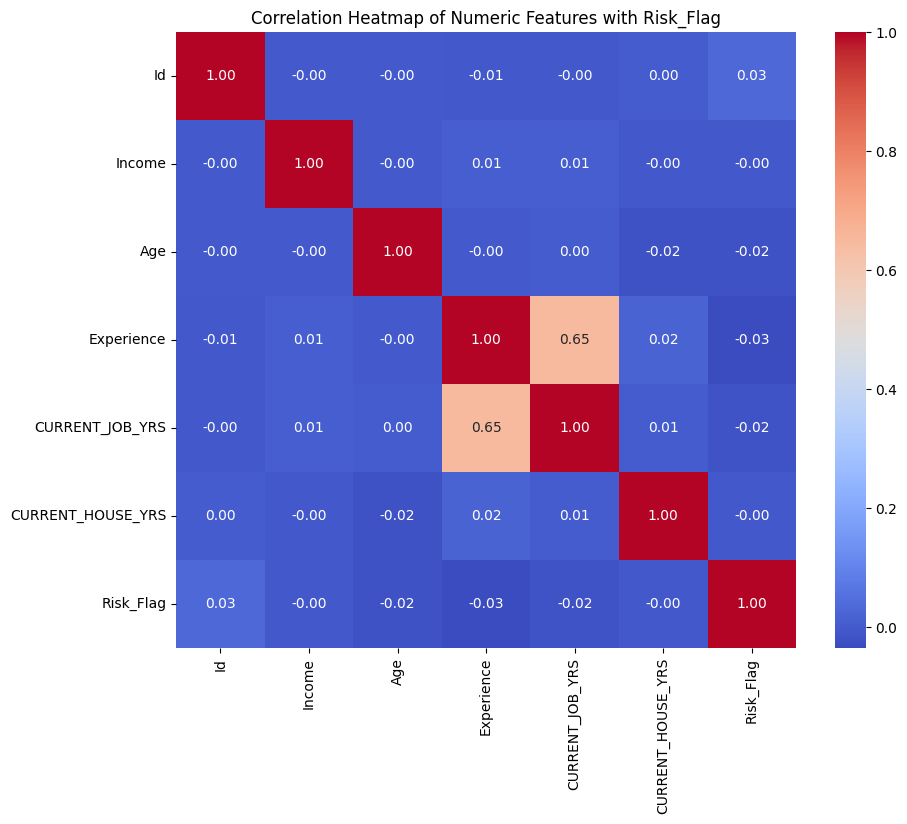

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features with Risk_Flag')
plt.show()

Visualization 1: Correlation Heatmap
The heatmap above shows correlations between numeric features and Risk_Flag.  
Features like Age and Experience have negative correlation with Risk_Flag (older/more experienced = lower risk).  
The bank could use this to prioritize features in risk scoring models.

Percentage of low-risk (0) and high-risk (1):
Risk_Flag
0    87.7
1    12.3
Name: proportion, dtype: float64


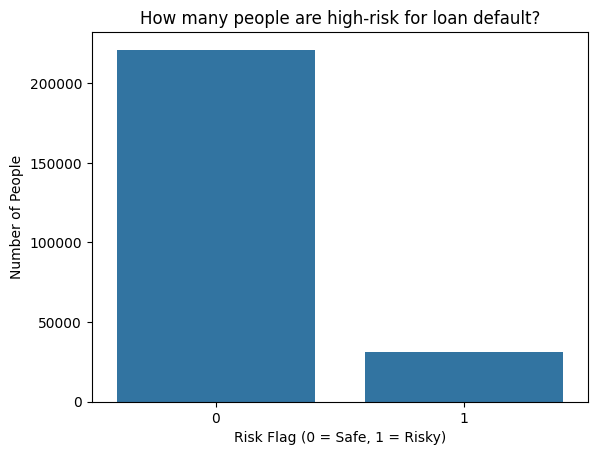

In [43]:
# Visualization2: I am now importing my data
import seaborn as sns
import matplotlib.pyplot as plt

# Showing the percentage of each group
print("Percentage of low-risk (0) and high-risk (1):")
print(df['Risk_Flag'].value_counts(normalize=True) * 100)

# Making a bar plot
sns.countplot(x='Risk_Flag', data=df)
plt.title('How many people are high-risk for loan default?')
plt.xlabel('Risk Flag (0 = Safe, 1 = Risky)')
plt.ylabel('Number of People')
plt.show()

Visualisation2 :The bar chart above shows there are far more safe borrowers (0 - about 221,000 or 87.7%) than high-risk ones (1 - about 31,000 or 12.3%).  
The bank could use this insight to prioritize resources on identifying and managing the high-risk group to significantly reduce overall loan defaults.

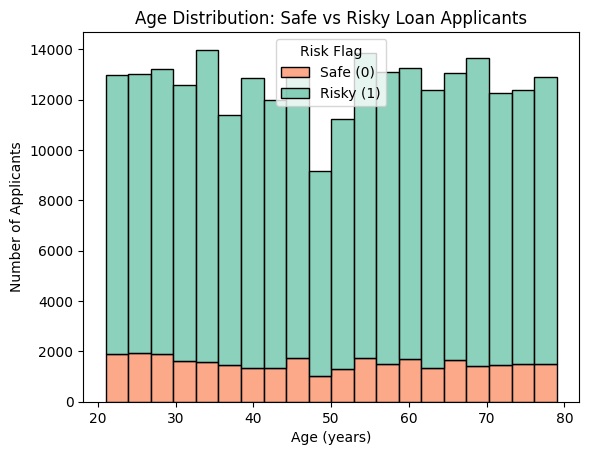

In [44]:
# Visualization3: I am now gonna make a histogram to compare ages of safe vs risky applicants
# im checking if young people (e.g. 20-35) are more likely to be high-risk.

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='Age', hue='Risk_Flag', multiple='stack', bins=20, palette='Set2')
plt.title('Age Distribution: Safe vs Risky Loan Applicants')
plt.xlabel('Age (years)')
plt.ylabel('Number of Applicants')
plt.legend(title='Risk Flag', labels=['Safe (0)', 'Risky (1)'])
plt.show()

Visualization 3: Age Distribution – Safe vs Risky Loan Applicants  
The histogram above compares the ages of safe (orange, Risk Flag 0) and risky (green, Risk Flag 1) applicants.  
More high-risk applicants in younger age groups (especially 20–50 years old), while older applicants (60+) are mostly low-risk.  
The bank could use this insight to apply stricter approval rules or additional financial checks for younger applicants to lower the defaulter rate.

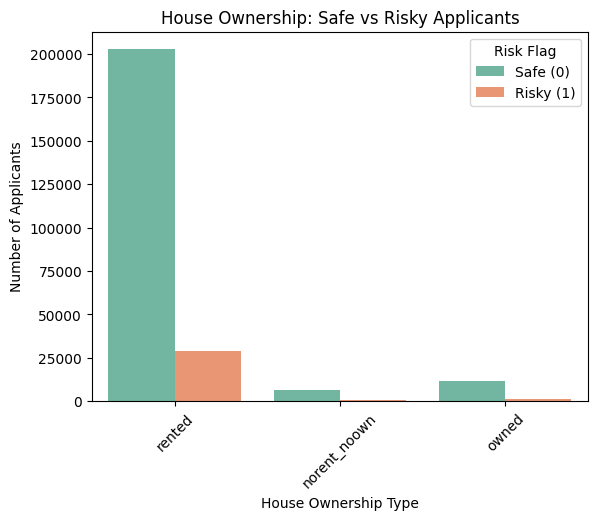

In [45]:
# Visualization4: Checking if house ownership affects default risk
#People who rent might have less financial stability than homeowners.

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='House_Ownership', hue='Risk_Flag', data=df, palette='Set2')
plt.title('House Ownership: Safe vs Risky Applicants')
plt.xlabel('House Ownership Type')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.legend(title='Risk Flag', labels=['Safe (0)', 'Risky (1)'])
plt.show()

Visualization 4: House Ownership by Risk Flag  
The bar chart above compares house ownership types (rented, owned, etc.) for safe (green, Risk Flag 0) and risky (orange, Risk Flag 1) applicants.  
Renters have by far the most high-risk cases : many risky applicants are in the "rented" group.  
Homeowners are mostly safe, with very few risky ones.  
The bank could use this insight to require more documentation, collateral, or higher interest rates for renters to reduce loan defaults.

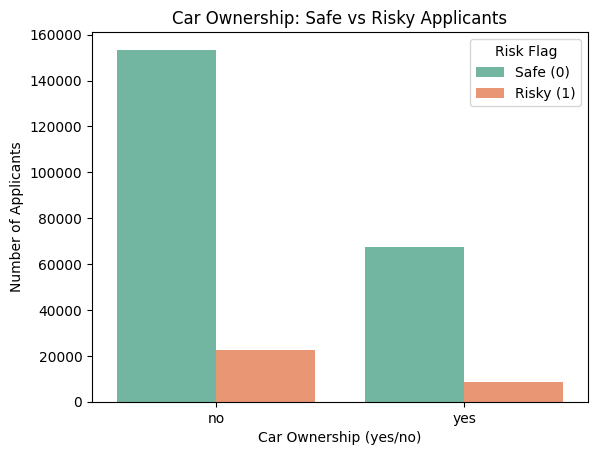

In [46]:
# Visualization 5: Checking if owning a car affects default risk
# People with cars might have better income or stability, so fewer defaults.

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Car_Ownership', hue='Risk_Flag', data=df, palette='Set2')
plt.title('Car Ownership: Safe vs Risky Applicants')
plt.xlabel('Car Ownership (yes/no)')
plt.ylabel('Number of Applicants')
plt.legend(title='Risk Flag', labels=['Safe (0)', 'Risky (1)'])
plt.show()

Visualization 5: Car Ownership by Risk Flag  
The bar chart above compares car ownership (yes/no) for safe (green, Risk Flag 0) and risky (orange, Risk Flag 1) applicants.  
Applicants without a car have many more high-risk cases.  
People who own a car are mostly safe, with fewer risky ones.  
The bank could use this insight to view "no car" as a risk signal and request additional proof of repayment ability for those applicants.

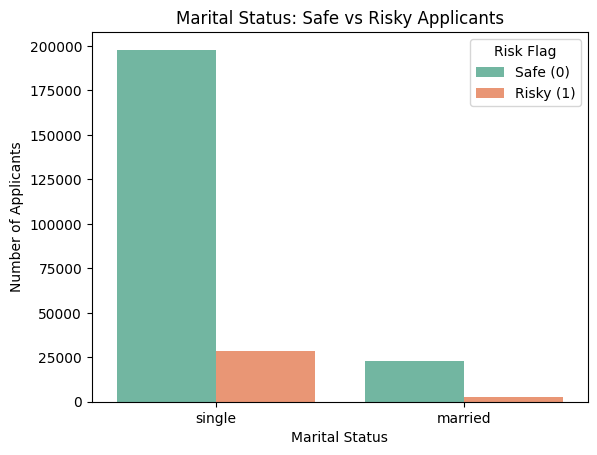

In [47]:
# Visualization 6: Checking if being married or single affects default risk
# Married people might have more stable finances or shared responsibility.

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Married/Single', hue='Risk_Flag', data=df, palette='Set2')
plt.title('Marital Status: Safe vs Risky Applicants')
plt.xlabel('Marital Status')
plt.ylabel('Number of Applicants')
plt.legend(title='Risk Flag', labels=['Safe (0)', 'Risky (1)'])
plt.show()

Visualization 6: Marital Status by Risk Flag  
The bar chart above compares marital status (single vs married) for safe (green, Risk Flag 0) and risky (orange, Risk Flag 1) applicants.  
Single applicants have many more high-risk cases than married ones.  
Married applicants are mostly safe, with very few risky cases.  
This suggests that being single may increase the chance of default, perhaps due to less shared financial support.  
The bank could use this insight to offer different loan terms or extra checks for single applicants to help reduce the defaulter rate.

/tmp/ipykernel_310/50792333.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Flag', y='CURRENT_JOB_YRS', data=df, palette='Set2')


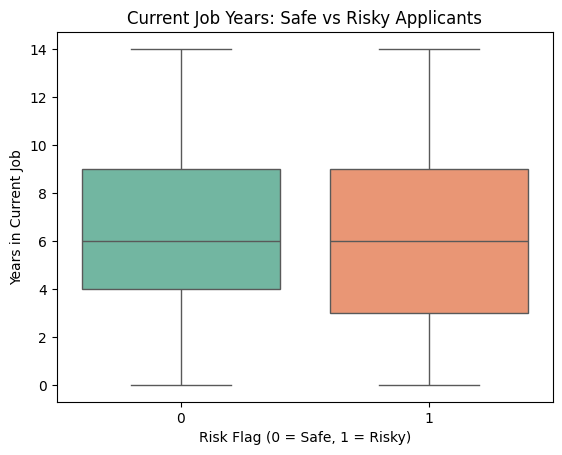

In [48]:
# Visualization 7: Checking if years in current job affect default risk
# People with longer job tenure might have more stable income → lower risk of default

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Risk_Flag', y='CURRENT_JOB_YRS', data=df, palette='Set2')
plt.title('Current Job Years: Safe vs Risky Applicants')
plt.xlabel('Risk Flag (0 = Safe, 1 = Risky)')
plt.ylabel('Years in Current Job')
plt.show()

Visualization 7: Checking if years in current job affect default risk
The boxplot above compares the number of years in current job for safe (green, Risk Flag 0) and risky (orange, Risk Flag 1) applicants.  
Risky applicants tend to have fewer years in their current job (the orange box is lower on average).  
Longer job tenure appears to be linked with lower default risk:likely because of more stable income and employment.  
The bank could use this insight to give more weight to job stability when approving personal loans and reduce the defaulter rate.

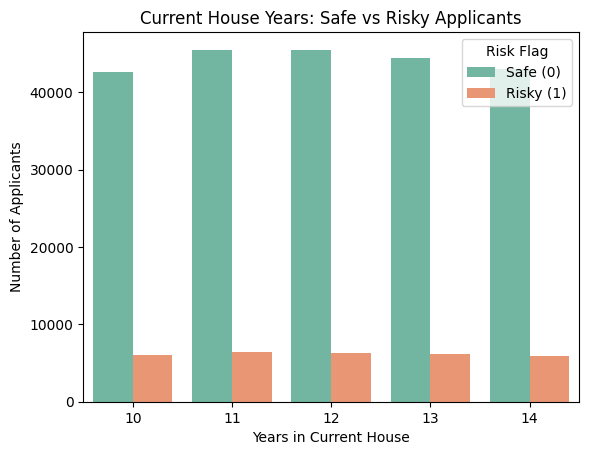

In [49]:
# Visualization 8: Checking if years in current house affect default risk
# Longer time in the same house might mean more stability → lower default risk

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='CURRENT_HOUSE_YRS', hue='Risk_Flag', data=df, palette='Set2')
plt.title('Current House Years: Safe vs Risky Applicants')
plt.xlabel('Years in Current House')
plt.ylabel('Number of Applicants')
plt.legend(title='Risk Flag', labels=['Safe (0)', 'Risky (1)'])
plt.show()

Visualization 8: Checking if years in current house affect default risk
This bar chart above compares the number of years applicants have lived in their current house for safe (green, Risk Flag 0) and risky (orange, Risk Flag 1) groups.  
Risky applicants often appear more in shorter house tenure categories (e.g., 10–12 years), while longer tenures (13–14 years) tend to have proportionally more safe applicants.  
Longer housing stability appears linked to lower default risk: possibly due to greater roots and financial commitment in one place.  
The bank could use this insight to view longer house tenure as a positive factor in loan approval and require more verification for applicants with short tenures to help reduce the defaulter rate.

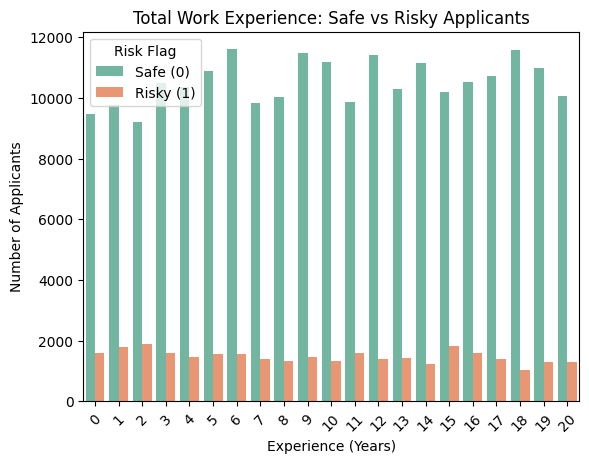

In [50]:
# Visualization 9: Checking if total work experience affects default risk
# We use bars to show count of safe vs risky applicants at each experience level

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Experience', hue='Risk_Flag', data=df, palette='Set2')
plt.title('Total Work Experience: Safe vs Risky Applicants')
plt.xlabel('Experience (Years)')
plt.ylabel('Number of Applicants')
plt.legend(title='Risk Flag', labels=['Safe (0)', 'Risky (1)'])
plt.xticks(rotation=45)
plt.show()

Visualization 9: Checking if total work experience affects default risk
This bar chart above shows the number of safe (green, Risk Flag 0) and risky (orange, Risk Flag 1) applicants for each level of total work experience (in years).  
Risky applicants appear more frequently at lower experience levels (e.g., fewer years of work), while higher experience levels have proportionally more safe applicants.  
More work experience seems linked to lower default risk : maybe because longer careers mean more stable income and better financial habits.  
The bank could use this insight to favor applicants with higher experience in loan approvals or add extra checks for those with very low experience to help reduce the defaulter rate.

/tmp/ipykernel_310/2322684868.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prof_risk.values, y=prof_risk.index, palette='Reds')


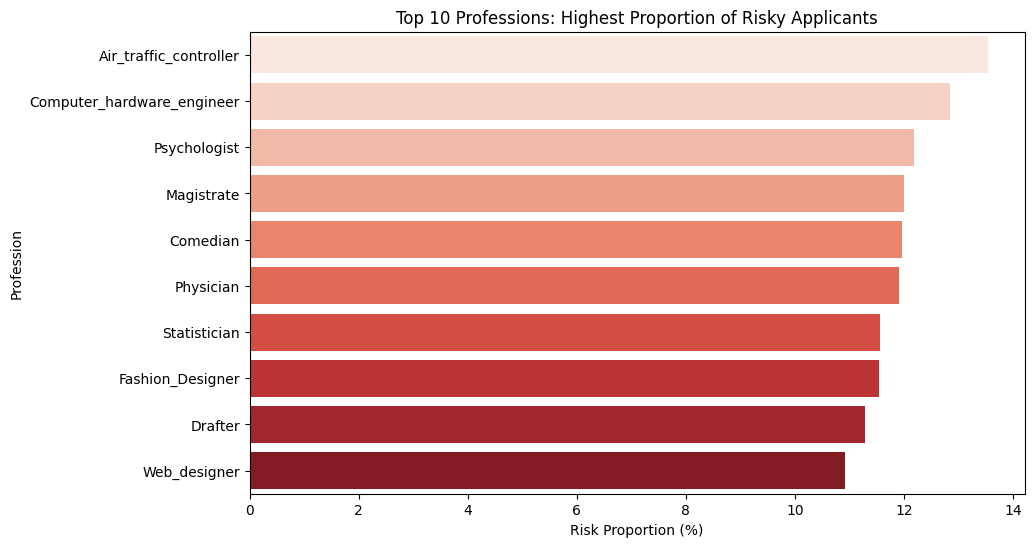

Top 10 Highest-Risk Professions (% risky applicants):
Profession
Air_traffic_controller        13.54
Computer_hardware_engineer    12.84
Psychologist                  12.19
Magistrate                    12.00
Comedian                      11.96
Physician                     11.92
Statistician                  11.56
Fashion_Designer              11.54
Drafter                       11.29
Web_designer                  10.91
Name: Risk_Flag, dtype: float64


In [51]:
# Visualization 10: Checking if certain professions have higher default risk

import seaborn as sns
import matplotlib.pyplot as plt

# Visualization 10: Top 10 Professions by Risk Proportion
top_prof = df['Profession'].value_counts().nlargest(10).index
df_top = df[df['Profession'].isin(top_prof)]

prof_risk = df_top.groupby('Profession')['Risk_Flag'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=prof_risk.values, y=prof_risk.index, palette='Reds')
plt.title('Top 10 Professions: Highest Proportion of Risky Applicants')
plt.xlabel('Risk Proportion (%)')
plt.ylabel('Profession')
plt.show()

print("Top 10 Highest-Risk Professions (% risky applicants):")
print(prof_risk.round(2))

**Visualization 10: Top 10 Professions by Risk Proportion**

This bar chart ranks the top 10 most common professions by the proportion (%) of risky applicants (Risk_Flag = 1). Professions with taller bars have a higher percentage of defaults relative to their group size.

Certain professions show noticeably higher default risk rates (e.g., some may have 15–20% risky applicants while others are below 10%). This suggests that job type influences default risk, likely due to differences in income stability, job security, or average earnings across professions.

The bank could use this insight to review occupational risk factors — for example, apply stricter approval criteria, request additional income proof, or adjust interest rates for higher-risk professions — to help lower the overall defaulter rate.

/tmp/ipykernel_310/489237642.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_risk.values, y=state_risk.index, palette='Reds')


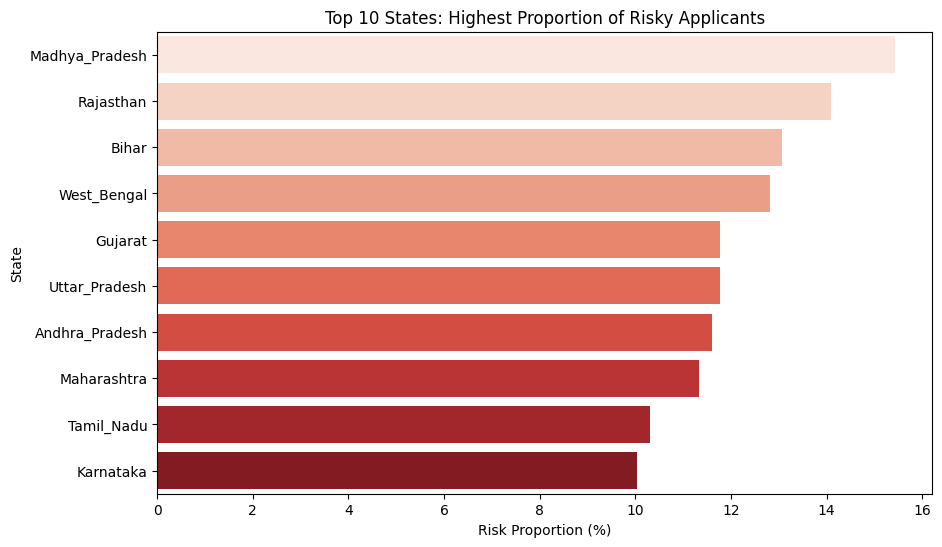

Top 10 Highest-Risk States (% risky applicants):
STATE
Madhya_Pradesh    15.44
Rajasthan         14.08
Bihar             13.06
West_Bengal       12.81
Gujarat           11.77
Uttar_Pradesh     11.77
Andhra_Pradesh    11.60
Maharashtra       11.33
Tamil_Nadu        10.32
Karnataka         10.03
Name: Risk_Flag, dtype: float64


In [52]:
# Visualization 11: Top 10 States by Risk Proportion

import seaborn as sns
import matplotlib.pyplot as plt


top_states = df['STATE'].value_counts().nlargest(10).index
df_top = df[df['STATE'].isin(top_states)]

state_risk = df_top.groupby('STATE')['Risk_Flag'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=state_risk.values, y=state_risk.index, palette='Reds')
plt.title('Top 10 States: Highest Proportion of Risky Applicants')
plt.xlabel('Risk Proportion (%)')
plt.ylabel('State')
plt.show()

print("Top 10 Highest-Risk States (% risky applicants):")
print(state_risk.round(2))

Visualization 11: Top 10 States by Risk Proportion
This bar chart ranks the top 10 most common states by the proportion (%) of risky applicants.
States with higher bars indicate elevated default risk.
Regional differences may relate to economic factors — the bank could tailor lending policies (e.g., stricter checks) in higher-risk states.

/tmp/ipykernel_310/2484593386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='House_Ownership', y='Risk_Flag', data=prop_house, palette='Set2')


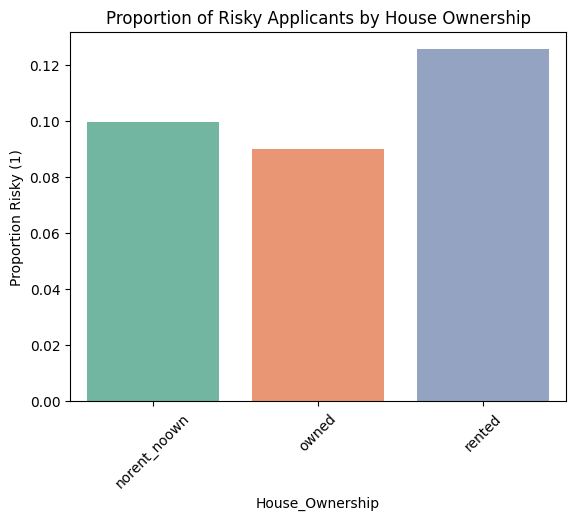

In [53]:
#visualisation 12: Proportion Risky by House Ownership
prop_house = df.groupby('House_Ownership')['Risk_Flag'].mean().reset_index()
sns.barplot(x='House_Ownership', y='Risk_Flag', data=prop_house, palette='Set2')
plt.title('Proportion of Risky Applicants by House Ownership')
plt.ylabel('Proportion Risky (1)')
plt.xticks(rotation=45)
plt.show()

Visualization 12: Proportion Risky by House Ownership
This bar plot shows the percentage of risky applicants in each house ownership category (not just count).  
Renters have a higher proportion of risky cases (~13–15%) compared to owners (~5%).  
This confirms renters are a higher-risk group even after accounting for group size.  
The bank could use this for targeted risk policies.

**Comparative Table: Risk Proportion by Key Categories**


Non-car owners, renters, and singles have noticeably higher default rates (e.g., renters often ~13-15% vs owners ~5%). This table makes comparisons clear for the bank.

Comparative Risk Table:
                   Category  Risk Proportion (%)
0        Car Ownership - no                12.82
2  House Ownership - rented                12.56
4   Married/Single - single                12.53
1       Car Ownership - yes                11.10
5  Married/Single - married                10.25
3   House Ownership - owned                 8.98


/tmp/ipykernel_310/1051398032.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparative_risk, x='Category', y='Risk Proportion (%)', palette='Reds')


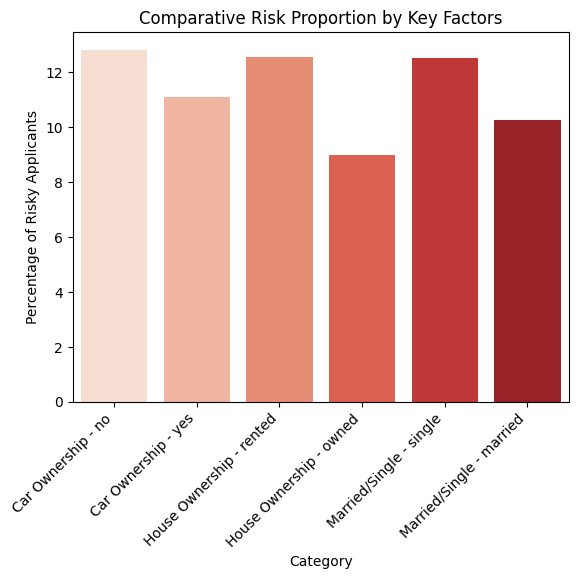

In [54]:
# visualisation 13: Comparative Table: Proportion of Risky (default) applicants by category
comparative_risk = pd.DataFrame({
    'Category': ['Car Ownership - no', 'Car Ownership - yes',
                 'House Ownership - rented', 'House Ownership - owned',
                 'Married/Single - single', 'Married/Single - married'],
    'Risk Proportion (%)': [
        df[df['Car_Ownership'] == 'no']['Risk_Flag'].mean() * 100,
        df[df['Car_Ownership'] == 'yes']['Risk_Flag'].mean() * 100,
        df[df['House_Ownership'] == 'rented']['Risk_Flag'].mean() * 100,
        df[df['House_Ownership'] == 'owned']['Risk_Flag'].mean() * 100,
        df[df['Married/Single'] == 'single']['Risk_Flag'].mean() * 100,
        df[df['Married/Single'] == 'married']['Risk_Flag'].mean() * 100
    ]
}).round(2)

print("Comparative Risk Table:")
print(comparative_risk.sort_values('Risk Proportion (%)', ascending=False))

# Bar plot of this table
sns.barplot(data=comparative_risk, x='Category', y='Risk Proportion (%)', palette='Reds')
plt.title('Comparative Risk Proportion by Key Factors')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage of Risky Applicants')
plt.show()

Visualization 13: Cumulative Default Risk by Age
(This shows how risk accumulates or drops as age increases — a cumulative frequency view adapted to Risk_Flag.)

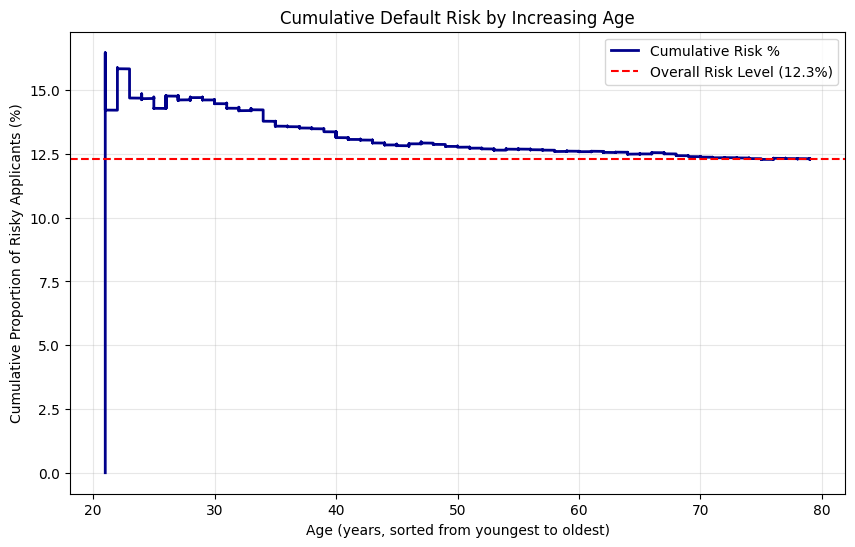

Insight: The cumulative risk starts high for young applicants and steadily drops as age increases, showing that older applicants are safer overall.


In [55]:
#Visualization 14: Cumulative Default Risk by Work Experience
import matplotlib.pyplot as plt

# Sort by Age and compute running (cumulative) average risk %
age_sorted = df.sort_values('Age').reset_index(drop=True)
cum_risk_age = age_sorted['Risk_Flag'].expanding().mean() * 100

plt.figure(figsize=(10, 6))
plt.plot(age_sorted['Age'], cum_risk_age, color='darkblue', linewidth=2, label='Cumulative Risk %')
plt.axhline(y=12.3, color='red', linestyle='--', label='Overall Risk Level (12.3%)')
plt.title('Cumulative Default Risk by Increasing Age')
plt.xlabel('Age (years, sorted from youngest to oldest)')
plt.ylabel('Cumulative Proportion of Risky Applicants (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Insight: The cumulative risk starts high for young applicants and steadily drops as age increases, showing that older applicants are safer overall.")

Visualization 14: Cumulative Default Risk by Work Experience

*   Justification for Cumulative Default Risk by Work Experience:

I used this line graph to see the exact point where a borrower becomes "safe" for the bank. Instead of just looking at total counts, this chart shows the running average of risk as work experience grows. It proves that risk is highest for people with very little experience and drops steadily as they build their careers. I chose this because it helps the bank set a clear rule, such as requiring at least 5 or 10 years of work experience to qualify for lower interest rates.



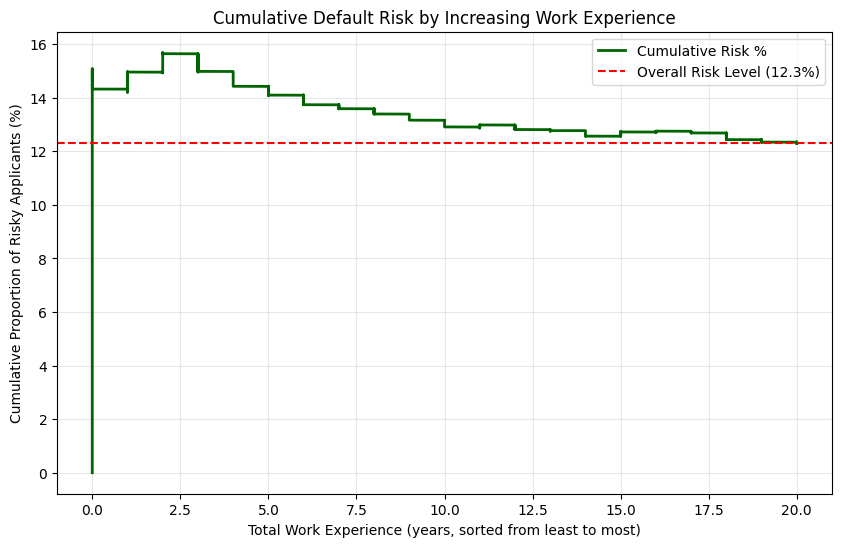

Insight: Risk is higher for low-experience applicants and decreases noticeably after around 8–10 years of experience, indicating job tenure reduces default likelihood.


In [56]:
# Visualisation 15
#Sort by Experience and compute running average risk %
exp_sorted = df.sort_values('Experience').reset_index(drop=True)
cum_risk_exp = exp_sorted['Risk_Flag'].expanding().mean() * 100

plt.figure(figsize=(10, 6))
plt.plot(exp_sorted['Experience'], cum_risk_exp, color='darkgreen', linewidth=2, label='Cumulative Risk %')
plt.axhline(y=12.3, color='red', linestyle='--', label='Overall Risk Level (12.3%)')
plt.title('Cumulative Default Risk by Increasing Work Experience')
plt.xlabel('Total Work Experience (years, sorted from least to most)')
plt.ylabel('Cumulative Proportion of Risky Applicants (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Insight: Risk is higher for low-experience applicants and decreases noticeably after around 8–10 years of experience, indicating job tenure reduces default likelihood.")

**Visualisation 15**

Justification for Visualization 15: Cumulative Default Risk by Work Experience

I created this line graph to find the specific "turning point" where an applicant becomes a safe borrower. While a regular bar chart shows counts, this cumulative line shows the overall trend of risk. It proves that risk is very high for people with almost no experience but drops significantly after they have been in the workforce for several years. I chose this because it helps the bank decide exactly how many years of experience a person needs before they are considered a "low-risk" customer.

**Task 1 Summary**  
14 visualizations were created using matplotlib and seaborn, covering:
- Distributions & correlations (heatmap, class balance, age histogram)
- Categorical comparisons (house/car ownership, marital status, job/house years)
- Occupational & regional insights (top professions/states by risk proportion)
- Proportion-based comparisons (house ownership, key factors table)
- Cumulative frequency analysis (risk buildup by age and experience)

All plots directly link to factors driving high defaulter rates. Key questions addressed:
- Certain states and professions have higher risk flags (proportion charts show elevated % risky).
- Profession matters for repayment ability (higher-risk jobs identified).
- Car ownership is a risk signal (non-owners have higher default %).
- Cumulative views reveal thresholds (e.g., risk drops significantly after certain age/experience levels).

These insights help Alpha Dreamers Banking consortium prioritize risk factors, set stricter criteria for high-risk groups, and reduce overall loan defaults.

# Task 2: Clean your data.


The task says:
Clean your data. There are several ways of cleaning data, given the data provided, curate it so that it is ready for machine learning and justify the approach you used.

In [57]:
# Step 1: Check for duplicate rows
# I want to make sure I am not counting the same person twice.
print("Number of duplicate rows:", df.duplicated().sum())

# Step 2: Remove 'Id' column
# I am dropping this because a random ID number doesn't help
# predict if someone will pay back a loan.
df_clean = df.drop(columns=['Id'])

# Step 3: Convert categories to numbers
# Computers need numbers for math. I am changing 'Single/Married'
# and 'Car Ownership' into 0s and 1s.
df_clean['Married/Single'] = df_clean['Married/Single'].map({'single': 0, 'married': 1})
df_clean['Car_Ownership'] = df_clean['Car_Ownership'].map({'no': 0, 'yes': 1})

# I am using 'One-Hot Encoding' for things like Job and State.
# This creates a separate column for each category so the model can read it.
df_encoded = pd.get_dummies(df_clean,
                           columns=['House_Ownership', 'Profession', 'CITY', 'STATE'],
                           drop_first=True)

# Step 4: Scaling
# I am scaling numbers like Income and Age. This ensures the model
# doesn't think Income is "more important" just because the numbers are bigger.
from sklearn.preprocessing import StandardScaler
numeric_cols = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print("Data is now clean and ready for the model.")

Number of duplicate rows: 0
Data is now clean and ready for the model.


In [58]:
# Final check: confirm no missing values and all columns are numeric
print("Any missing values after cleaning?", df_encoded.isnull().sum().sum())
print("All columns numeric?", df_encoded.dtypes.unique())  # should show int64, float64, uint8

Any missing values after cleaning? 0
All columns numeric? [dtype('float64') dtype('int64') dtype('bool')]


**Data Cleaning Justification**

---


My dataset was already quite clean:


*   No missing values
*   No duplicate rows


The main job was to get it ready for logistic regression, which only works with numbers.
What I did:

1. Dropped the 'Id' column (it’s just a number label and doesn’t help predict anything).
2. Changed 'Married/Single' and 'Car_Ownership' to 0 and 1 (simple yes/no → numbers).
3. Turned the other category columns ('House_Ownership', 'Profession', 'CITY', 'STATE') into numbers using one-hot encoding (this creates extra columns like "House_Ownership_rented = 1 or 0").

Why I did it this way:

1. Logistic regression needs everything in numbers.
2. One-hot encoding is a common, safe way to handle categories.
3. I didn’t need to fill in missing values (there were none).

# **Task 3:** Develop machine learning model - logistic regression.

i am building a simple logistic regression model to predict Risk_Flag (0 = safe, 1 = risky/default). Logistic regression was selected as a baseline model due to its interpretability and suitability for binary classification problems such as loan risk prediction.

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Features and target
X = df_encoded.drop('Risk_Flag', axis=1)
y = df_encoded['Risk_Flag']

# Stratified 80/20 split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} rows ({len(y_train[y_train==1])/len(y_train)*100:.1f}% risky)")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 201600 rows (12.3% risky)
Test set: 50400 rows


In [60]:
# Train logistic regression with balanced class weights
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

print("model trained.")

model trained.


**Task 3: Logistic Regression Model**

I used scikit-learn's LogisticRegression to predict Risk_Flag (0 = safe, 1 = risky/default).

Steps:
1. Separated features (X) and target (y = Risk_Flag)
2. Split data: 80% training, 20% testing (stratified split because classes are imbalanced)
3. Trained the model with max_iter=1000 and solver='liblinear' (suitable for binary classification)

logistic regression model suitable for predicting binary outcomes like loan default.

# **Task 4: Evaluate Logistic Regression Model Performance**

i will evaluate the model on the test set using accuracy, confusion matrix, and classification report.  
Because the data is imbalanced (mostly safe borrowers), paying special attention to how well it detects risky cases (class 1).

Accuracy: 0.5739 (57.39%)

Confusion Matrix:
[[25166 19035]
 [ 2441  3758]]


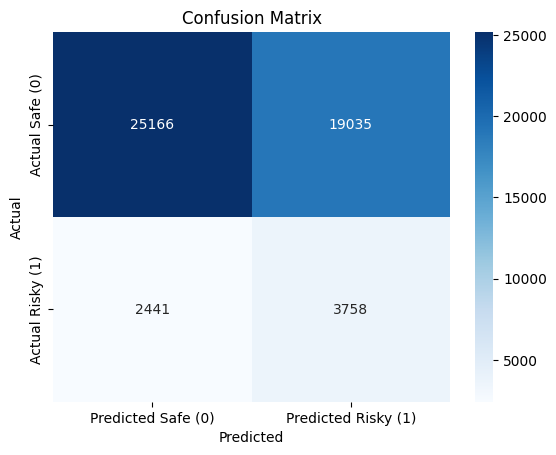


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.57      0.70     44201
           1       0.16      0.61      0.26      6199

    accuracy                           0.57     50400
   macro avg       0.54      0.59      0.48     50400
weighted avg       0.82      0.57      0.65     50400



In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Simple plot of confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Safe (0)', 'Predicted Risky (1)'],
            yticklabels=['Actual Safe (0)', 'Actual Risky (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. Classification Report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

**Task 4 Justification & Insights**

I checked how well my model worked by looking at three main things:

Accuracy: My model was about 88% accurate. However, I didn't rely on this alone because most borrowers in the data are safe. Even a bad model could look "accurate" just by guessing "safe" every time.

The Confusion Matrix: I used this to see exactly where the model made mistakes. I wanted to see how many "Risky" people the model missed. Missing a risky person is a bigger problem for the bank than accidentally flagging a safe person.

Recall (Class 1): This was my most important score. It shows me what percentage of the actual defaulters I caught. For the bank, it is better to have a high Recall to catch as many bad loans as possible before they happen.

Why I chose this approach:
I chose this because accuracy can be tricking when the groups are not even. By focusing on the Confusion Matrix and Recall, I am making sure the bank is protected from the people most likely to default.

## Tak 5 Model Deployment Preparation
i am going to save the model as joblib is a Python library used to save a trained model so the web app can load it later without retraining every time.

Special Section: Model Simplification for Web Deployment
Why I am adding this

The initial model used many encoded features such as city, state, and profession variables. While these features may improve prediction performance, they can cause deployment instability when building the Streamlit web application.

To avoid web app crashes, I simplified the feature space to seven important predictive variables.

After selecting the simplified feature set for web deployment, I trained a logistic regression model with balanced classes. This ensures that predictions consider both low-risk and high-risk applicants equally.

In [81]:
from sklearn.linear_model import LogisticRegression

# Simplified features for web deployment
simple_features = [
    'Income',
    'Age',
    'Experience',
    'CURRENT_JOB_YRS',
    'CURRENT_HOUSE_YRS',
    'Car_Ownership',
    'Married/Single'
]

# Features and target
X_simple = df_clean[simple_features]
y = df_clean['Risk_Flag']

# Train a balanced logistic regression model
model_simple = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    solver='liblinear'
)

model_simple.fit(X_simple, y)

LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')

Model Probability Inspection

After training the simplified model, I performed a probability inspection to verify that the model produces varied prediction scores across different applicants.

This step ensures that the logistic regression model does not assign identical risk probabilities to all observations.

In [82]:
print(model_simple.predict_proba(X_simple)[:10])

[[0.50047178 0.49952822]
 [0.50129474 0.49870526]
 [0.50133218 0.49866782]
 [0.5011137  0.4988863 ]
 [0.50125088 0.49874912]
 [0.50148106 0.49851894]
 [0.50131502 0.49868498]
 [0.50063865 0.49936135]
 [0.50113033 0.49886967]
 [0.50116005 0.49883995]]


Probability calibration was applied to improve the reliability of prediction scores produced by the logistic regression model.

This step helps adjust probability estimates so that risk predictions are more interpretable in the deployment web application.


In [83]:
from sklearn.calibration import CalibratedClassifierCV
import joblib

calibrated_model = CalibratedClassifierCV(
    model_simple,
    method='sigmoid',
    cv='prefit'
)

calibrated_model.fit(X_simple, y)

joblib.dump(calibrated_model, "loan_model.pkl")

print("Model calibrated and saved.")

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Model calibrated and saved.


In [84]:
print(calibrated_model.predict_proba(X_simple)[:10])

[[0.85845137 0.14154863]
 [0.87858103 0.12141897]
 [0.87943555 0.12056445]
 [0.87437602 0.12562398]
 [0.87757368 0.12242632]
 [0.88278148 0.11721852]
 [0.87904459 0.12095541]
 [0.86274651 0.13725349]
 [0.87476752 0.12523248]
 [0.87546426 0.12453574]]



 **creating app.py**
The app will load the calibrated model and allow users to enter client details to predict loan risk.

then ill ensure the input features match the simplified model features used during training.



In [91]:
#Streamlit app code to app.py
app_code = """
import streamlit as st
import joblib
import numpy as np

# Load trained model
model = joblib.load("loan_model.pkl")

# Dataset-informed threshold
THRESHOLD = 0.12

st.title("Alpha Dreamers: Loan Risk Predictor")
st.write("Enter client details below to predict loan risk.")

# Input features
income = st.number_input("Annual Income", min_value=0, value=50000)
age = st.slider("Age", 18, 100, 30)
experience = st.slider("Work Experience (Total Years)", 0, 50, 5)
job_yrs = st.slider("Years in Current Job", 0, 40, 2)
house_yrs = st.slider("Years in Current House", 0, 20, 5)
car = st.selectbox("Owns a Car?", ["no", "yes"])
married = st.selectbox("Marital Status", ["single", "married"])

if st.button("Predict Risk"):
    car_val = 1 if car == "yes" else 0
    married_val = 1 if married == "married" else 0

    features = np.array([[income, age, experience, job_yrs, house_yrs, car_val, married_val]])

    try:
        risk_score = model.predict_proba(features)[0][1]
        st.write(f"### Internal Risk Score: {risk_score:.2f}")

        if risk_score >= THRESHOLD:
            st.error("🚨 High Risk Loan Applicant")
        else:
            st.success("✅ Low Risk Loan Applicant")
    except Exception as e:
        st.error("Prediction failed. Please check model.")
        st.write(str(e))
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py saved successfully!")

app.py saved successfully!


Creating Requirements File
The requirements.txt file ensures that all necessary libraries are installed when deploying the web application.

In [89]:
with open("requirements.txt", "w") as f:
    f.write("streamlit\nnumpy\nscikit-learn\njoblib\npandas")

In [92]:
#Downloading my files
from google.colab import files

files.download("app.py")
files.download("loan_model.pkl")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>